In [ ]:
import pandas as pd
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import learning_curve, ShuffleSplit
from sklearn.metrics import make_scorer
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()
#to upload the development.csv, evaluation.csv,sample_submission.csv

Saving development.csv to development.csv
Saving evaluation.csv to evaluation.csv
Saving sample_submission.csv to sample_submission.csv


In [ ]:
train = pd.read_csv('development.csv')
eval_data = pd.read_csv('evaluation.csv')


In [ ]:
train['text'] = train['title'] + " " + train['article']
eval_data['text'] = eval_data['title'] + " " + eval_data['article']


In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def clean_text(text):
    text = str(text).lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    text = ''.join([c for c in text if not c.isdigit()])
    words = text.split()
    words = [w for w in words if w not in ENGLISH_STOP_WORDS and len(w) > 2]
    return ' '.join(words)
train['clean_title'] = train['title'].apply(clean_text)
train['clean_article'] = train['article'].apply(clean_text)

eval_data['clean_title'] = eval_data['title'].apply(clean_text)
eval_data['clean_article'] = eval_data['article'].apply(clean_text)
#okay we lowercased everything and removed punctuation, numbers and we created a list of words without common words so we can give it to tfidf

In [ ]:
X_train_full = train[['clean_title','clean_article', 'source', 'page_rank']]
y_train_full = train['label']

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)


In [ ]:

title_tfidf = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=16000,
        ngram_range=(1,3),
        min_df=3,max_df=0.85,
        sublinear_tf=True,
        smooth_idf=True, norm='l2'
    ))
])
article_tfidf = Pipeline([
    ('tfidf', TfidfVectorizer(
        max_features=28000,
        ngram_range=(1,3),
        min_df=5, max_df=0.8,
        sublinear_tf=True, smooth_idf=True, norm='l2'
    ))
])


In [ ]:
metadata_pipeline = ColumnTransformer(transformers=[
    ('source', OneHotEncoder(handle_unknown='ignore'), ['source']),
    ('pagerank', StandardScaler(), ['page_rank']),
])

In [ ]:

preprocessor = ColumnTransformer(
    transformers=[
        ('title', title_tfidf, 'clean_title'),
        ('article', article_tfidf, 'clean_article'),
        ('meta', metadata_pipeline, ['source', 'page_rank'])
    ],
    remainder='drop'
)

In [ ]:
pipeline = Pipeline([
    ('features', preprocessor),
    ('clf', LogisticRegression(
        C=0.8, penalty='l2', solver='liblinear',
        max_iter=2000, dual=True,
        class_weight='balanced', random_state=42
    ))
])



In [ ]:
from sklearn.model_selection import cross_val_score
import numpy as np
import matplotlib.pyplot as plt

n_samples = len(X_train_full)
sizes = np.round(np.linspace(0.2, 1.0, 5) * n_samples).astype(int)
train_f1, cv_f1 = [], []

for size in sizes:
    print(f"Size {size}...")
    X_trunc = X_train_full.iloc[:size]
    y_trunc = y_train_full.iloc[:size]
    cv_scores = cross_val_score(pipeline, X_trunc, y_trunc, cv=3, scoring='f1_macro')
    cv_f1.append(cv_scores.mean())

    pipeline.fit(X_trunc, y_trunc)
    train_f1.append(f1_score(y_trunc, pipeline.predict(X_trunc), average='macro'))

plt.figure(figsize=(10,6))
plt.plot(sizes, train_f1, 'b-o', label='Training F1')
plt.plot(sizes, cv_f1, 'r-o', label='CV F1')
plt.xlabel('Training Size'); plt.ylabel('Macro F1'); plt.legend(); plt.grid(True)
plt.title('Learning Curve'); plt.show()


Size 15999...


KeyboardInterrupt: 

In [ ]:
pipeline.fit(X_train_full, y_train_full)
print("Holdout F1:", f1_score(y_val, pipeline.predict(X_val), average='macro'))

Holdout F1: 0.8257826914385852


In [ ]:
pipeline.fit(X_train, y_train)

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipython-input-3809708124.py", line 1, in <cell line: 0>
    pipeline.fit(X_train, y_train)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 654, in fit
    Xt = self._fit(X, y, routed_params, raw_params=params)
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py", line 588, in _fit
    X, fitted_transformer = fit_transform_one_cached(
                            ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/joblib/memory.py", line 326, in __call__
    return self.func(*a

In [ ]:
y_val_pred = pipeline.predict(X_val)
score = f1_score(y_val, y_val_pred, average='macro')
print("Validation Macro F1:", score)

Validation Macro F1: 0.8257826914385852


In [ ]:

eval_features = eval_data[['clean_title', 'clean_article', 'source', 'page_rank']]
eval_preds = pipeline.predict(eval_features)

In [ ]:
submission = pd.DataFrame({
    'Id': eval_data['Id'],
    'Predicted': eval_preds
})
submission.to_csv('submission.csv', index=False)
print(submission.head())


   Id  Predicted
0   0          5
1   1          2
2   2          0
3   3          0
4   4          0


In [ ]:
from google.colab import files
files.download('submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

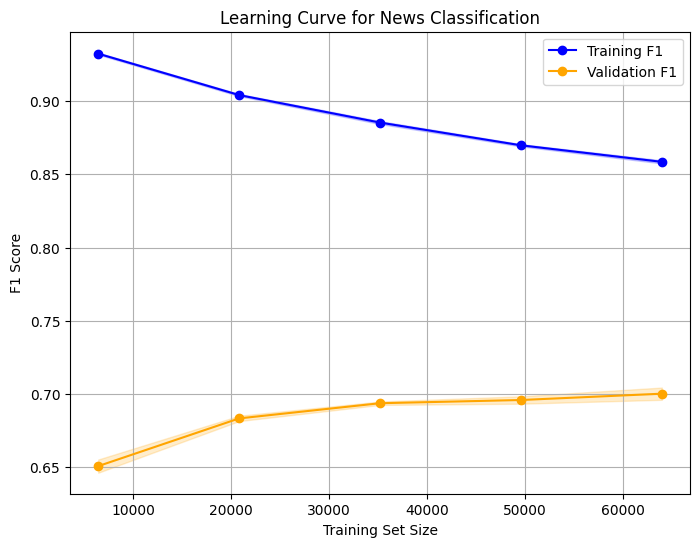